In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/imdb_cleaned.csv")

df.head()

,Title,Year,Genres,Rating,Votes,Decade
0,Kate & Leopold,2001,"Comedy,Fantasy,Romance",6.4,93592,2000
1,All About Eve,1950,Drama,8.2,148495,1950
2,Cinderella,1950,"Animation,Family,Fantasy",7.3,186052,1950
3,Harvey,1950,"Comedy,Drama,Fantasy",7.9,60798,1950
4,Rashomon,1950,"Crime,Drama,Mystery",8.1,195453,1950


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4487 entries, 0 to 4486
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   4487 non-null   str    
 1   Year    4487 non-null   int64  
 2   Genres  4487 non-null   str    
 3   Rating  4487 non-null   float64
 4   Votes   4487 non-null   int64  
 5   Decade  4487 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 210.5 KB


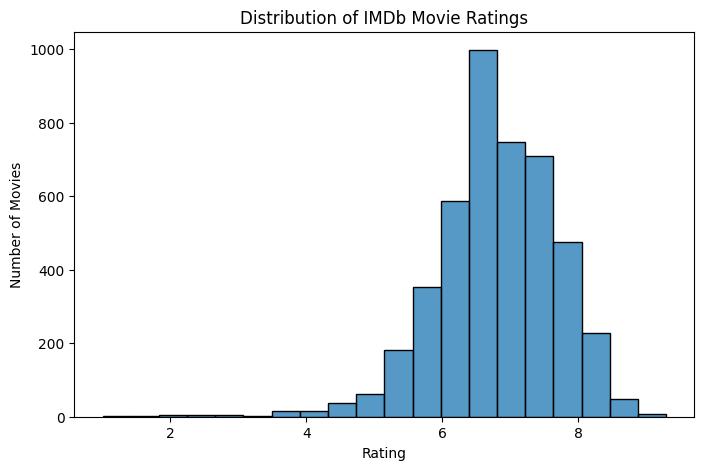

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=20)
plt.title("Distribution of IMDb Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

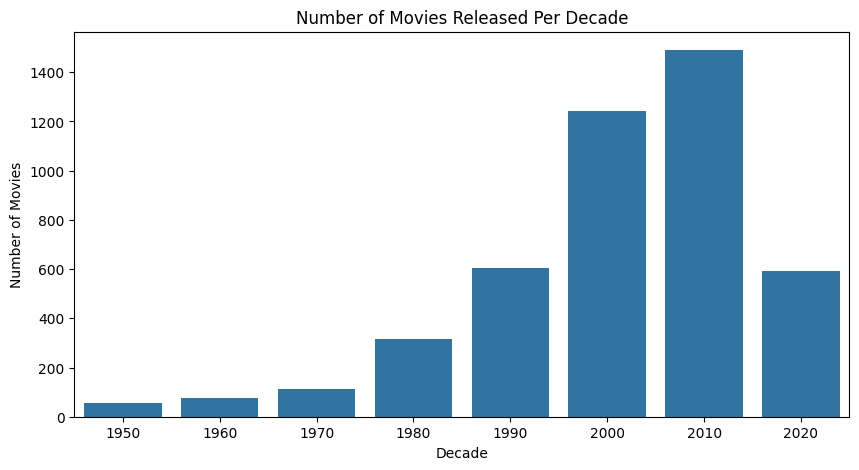

In [6]:
decade_counts = df["Decade"].value_counts().sort_index()

plt.figure(figsize=(10,5))
sns.barplot(x=decade_counts.index, y=decade_counts.values)

plt.title("Number of Movies Released Per Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Movies")

plt.show()

In [7]:
top_movies = df.sort_values(by="Rating", ascending=False).head(10)

top_movies[["Title", "Rating", "Votes"]]

,Title,Rating,Votes
775,The Shawshank Redemption,9.3,3164347
152,The Godfather,9.2,2209920
2092,The Dark Knight,9.1,3141794
724,Schindler's List,9.0,1576141
180,The Godfather Part II,9.0,1484976
1196,The Lord of the Rings: The Return of the King,9.0,2149997
39,12 Angry Men,9.0,976110
1034,The Lord of the Rings: The Fellowship of the Ring,8.9,2190851
1197,The Lord of the Rings: The Two Towers,8.8,1942915
768,Pulp Fiction,8.8,2418697


In [8]:
df["Genres"].head()

0      Comedy,Fantasy,Romance
1                       Drama
2    Animation,Family,Fantasy
3        Comedy,Drama,Fantasy
4         Crime,Drama,Mystery
Name: Genres, dtype: str

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer

df["Genres"] = df["Genres"].str.split(",")

mlb = MultiLabelBinarizer()

genre_features = pd.DataFrame(
    mlb.fit_transform(df["Genres"]),
    columns=mlb.classes_,
    index=df.index
)

df_ml = pd.concat([df, genre_features], axis=1)

df_ml.head()

,Title,Year,Genres,Rating,Votes,Decade,Action,Adventure,Animation,Biography,...,Musical,Mystery,News,Romance,Sci-Fi,Sport,Thriller,War,Western,\N
0,Kate & Leopold,2001,"[Comedy, Fantasy, Romance]",6.4,93592,2000,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,All About Eve,1950,[Drama],8.2,148495,1950,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Cinderella,1950,"[Animation, Family, Fantasy]",7.3,186052,1950,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,Harvey,1950,"[Comedy, Drama, Fantasy]",7.9,60798,1950,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Rashomon,1950,"[Crime, Drama, Mystery]",8.1,195453,1950,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [10]:
features = ["Year", "Votes"] + list(mlb.classes_)

X = df_ml[features]
y = df_ml["Rating"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [13]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.46507007795100236


In [14]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

Votes          0.416744
Year           0.222062
Drama          0.117358
Action         0.025018
Animation      0.022377
Adventure      0.019393
Comedy         0.017854
Crime          0.017657
Fantasy        0.015629
Documentary    0.015576
dtype: float64